(80, 3)
(80, 1)
Epoch    0   Loss = 0.488543
Epoch  100   Loss = 0.045559
Epoch  200   Loss = 0.045459
Epoch  300   Loss = 0.045364
Epoch  400   Loss = 0.045272
Epoch  500   Loss = 0.045181
Epoch  600   Loss = 0.045092
Epoch  700   Loss = 0.045004
Epoch  800   Loss = 0.044916
Epoch  900   Loss = 0.044828
MSE : 2.6740
MAE : 1.3977


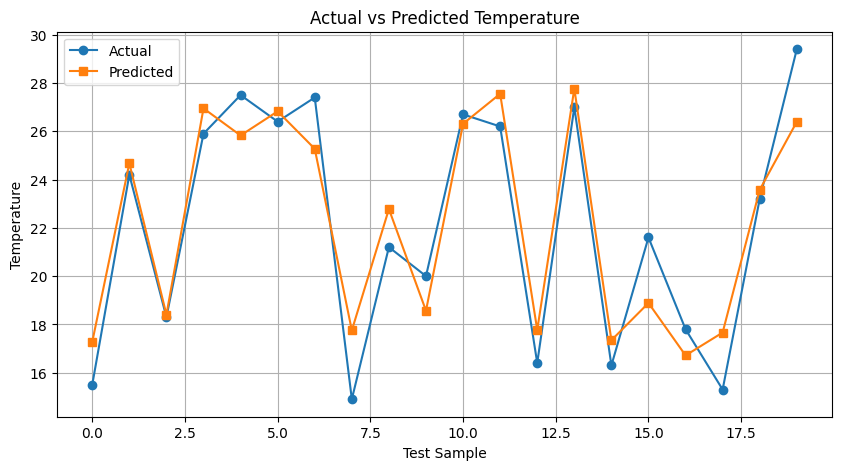

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load Data
df = pd.read_csv("temp_vanilla.csv")

X = df[[
    "temp_morning",
    "temp_afternoon",
    "temp_evening"
]].values

y = df["next_day_temp"].values.reshape(-1, 1)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(y_train.shape)

# =====================================================
# STANDARD SCALING
# =====================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test  = x_scaler.transform(X_test)

y_train       = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# =====================================================
# MLP PARAMETERS
# =====================================================

input_size    = 3   # d = 3   (morning, afternoon, evening)
hidden_size_1 = 16  # h1 = 16
hidden_size_2 = 8   # h2 = 8
output_size   = 1   # k  = 1

learning_rate = 0.001
epochs = 1000

# =====================================================
# WEIGHTS
# =====================================================

# np.random.seed(42)

# Layer 1 :  input  -> hidden 1
W1 = np.random.randn(hidden_size_1, input_size) * 0.1
b1 = np.zeros((hidden_size_1, 1))

# Layer 2 :  hidden 1 -> hidden 2
W2 = np.random.randn(hidden_size_2, hidden_size_1) * 0.1
b2 = np.zeros((hidden_size_2, 1))

# Layer 3 :  hidden 2 -> output   (linear output for regression)
W3 = np.random.randn(output_size, hidden_size_2) * 0.1
b3 = np.zeros((output_size, 1))

# =====================================================
# TRAINING
# =====================================================

loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for n in range(len(X_train)):

        # ==========================================
        # INPUT AND TARGET
        # ==========================================

        x = X_train[n].reshape(-1, 1)          # shape (d, 1)
        target = np.array([[y_train[n, 0]]])   # shape (k, 1)

        # ==========================================
        # FORWARD PASS
        # ==========================================

        z1 = W1 @ x  + b1
        a1 = np.tanh(z1)

        z2 = W2 @ a1 + b2
        a2 = np.tanh(z2)

        y_hat = W3 @ a2 + b3   # linear output

        loss = 0.5 * np.sum((y_hat - target) ** 2)
        total_loss += loss

        # ==========================================
        # OUTPUT LAYER GRADIENT
        # ==========================================

        dy  = y_hat - target       # dL / d y_hat

        dW3 = dy @ a2.T
        db3 = dy

        # ==========================================
        # HIDDEN LAYER 2 GRADIENT
        # ==========================================

        da2 = W3.T @ dy
        dz2 = da2 * (1 - a2 ** 2)  # tanh'(z2) = 1 - a2^2

        dW2 = dz2 @ a1.T
        db2 = dz2

        # ==========================================
        # HIDDEN LAYER 1 GRADIENT
        # ==========================================

        da1 = W2.T @ dz2
        dz1 = da1 * (1 - a1 ** 2)  # tanh'(z1) = 1 - a1^2

        dW1 = dz1 @ x.T
        db1 = dz1

        # ==========================================
        # WEIGHT UPDATE
        # ==========================================

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

    loss_history.append(total_loss)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d}   Loss = {total_loss / len(X_train):.6f}"
        )

# =====================================================
# TESTING
# =====================================================

predictions = []

for n in range(len(X_test)):

    x = X_test[n].reshape(-1, 1)

    z1 = W1 @ x  + b1
    a1 = np.tanh(z1)

    z2 = W2 @ a1 + b2
    a2 = np.tanh(z2)

    y_hat = W3 @ a2 + b3

    predictions.append(y_hat[0, 0])

predictions = np.array(predictions).reshape(-1, 1)

# =====================================================
# INVERSE TRANSFORM
# =====================================================

predictions = y_scaler.inverse_transform(predictions)

actual = y_test

# =====================================================
# EVALUATION
# =====================================================

mse = mean_squared_error(actual, predictions)
mae = mean_absolute_error(actual, predictions)
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")

# ==========================================
# ACTUAL VS PREDICTED PLOT
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    actual,
    label="Actual",
    marker='o'
)

plt.plot(
    predictions,
    label="Predicted",
    marker='s'
)

plt.xlabel("Test Sample")
plt.ylabel("Temperature")

plt.title("Actual vs Predicted Temperature")

plt.legend()

plt.grid(True)

plt.show()